<p align="center">
  <a href="https://github.com/wavekat/wavekat-lab">
    <img src="https://github.com/wavekat/wavekat-brand/raw/main/assets/banners/wavekat-lab-narrow.svg" alt="WaveKat Lab">
  </a>
</p>

# 01 — Parse MagicData-RAMC

Read every `MDT2021S003/TXT/*.txt` session transcript shipped with
MagicData-RAMC, parse the per-utterance rows
(`[start,end]\tspeaker_id\tgender,language\ttranscription`), flag the
special markers (`[+]` overlap, `[*]` unintelligible, `[LAUGHTER]`,
`[SONANT]`, `[MUSIC]`), and save the result as a single Parquet table
that downstream notebooks consume.

This is the foundation of the RAMC mining pipeline described in
[`../smart-turn/docs/03-magicdata-ramc-mining.md`](../smart-turn/docs/03-magicdata-ramc-mining.md).
Every later notebook in this folder reads `utterances.parquet` and
joins on `(session_id, utt_idx)`.

## Configure paths

Inputs come from the RAMC corpus checked out under `datasets/`.
Outputs go to `datasets/smart-turn-zh-mining/` — gitignored, treated
as a derived dataset.

In [1]:
from pathlib import Path

RAMC_ROOT = Path("../../datasets/MagicData-RAMC/MDT2021S003").resolve()
TXT_DIR = RAMC_ROOT / "TXT"
WAV_DIR = RAMC_ROOT / "WAV"

OUT_DIR = Path("../../datasets/smart-turn-zh-mining").resolve()
OUT_DIR.mkdir(parents=True, exist_ok=True)

UTTERANCES_PARQUET = OUT_DIR / "utterances.parquet"

print(f"RAMC TXT dir : {TXT_DIR.name}")
print(f"RAMC WAV dir : {WAV_DIR.name}")
print(f"Output       : {OUT_DIR.name}/{UTTERANCES_PARQUET.name}")
print("✅ paths configured")

RAMC TXT dir : TXT
RAMC WAV dir : WAV
Output       : smart-turn-zh-mining/utterances.parquet
✅ paths configured


## Discover sessions

We only keep TXT files that have a matching WAV — anything else
would just sit in the table with no audio behind it.

In [2]:
txt_files = sorted(TXT_DIR.glob("*.txt"))
wav_stems = {p.stem for p in WAV_DIR.glob("*.wav")}

paired = [t for t in txt_files if t.stem in wav_stems]
missing_wav = [t for t in txt_files if t.stem not in wav_stems]
missing_txt = sorted(wav_stems - {t.stem for t in txt_files})

print(f"TXT files       : {len(txt_files)}")
print(f"WAV files       : {len(wav_stems)}")
print(f"Paired sessions : {len(paired)}")
print(f"TXT without WAV : {len(missing_wav)}")
print(f"WAV without TXT : {len(missing_txt)}")
for stem in missing_wav[:3]:
    print(f"  no wav: {stem.name}")
for stem in missing_txt[:3]:
    print(f"  no txt: {stem}")
print("✅ sessions discovered")

TXT files       : 351
WAV files       : 349
Paired sessions : 349
TXT without WAV : 2
WAV without TXT : 0
  no wav: CTS-CN-F2F-2019-11-04-387.txt
  no wav: CTS-CN-F2F-2019-11-11-193.txt
✅ sessions discovered


## TXT row parser

Format (per `MDT2021S003/README.txt`):

```
[start_time,end_time]\tspeaker_id\tgender,language\ttranscription
```

Markers we flag for downstream filtering:

| Marker | Meaning | Mining decision |
|---|---|---|
| `[+]` | Overlapping speech | reject (diarization unreliable here) |
| `[*]` | Unintelligible / foreign-language passage | reject if dominant |
| `[LAUGHTER]` | Laughter | hold out as a stratified bucket |
| `[SONANT]` | Cough / sneeze / throat-clear | usually `G00000000`, drop |
| `[MUSIC]` | Music or humming | drop |

Speaker `G00000000` is RAMC's catch-all for non-speech events (the
TXT spec describes this row class).

In [3]:
import re

_RANGE_RE = re.compile(r"^\[(?P<start>-?\d+(?:\.\d+)?),(?P<end>-?\d+(?:\.\d+)?)\]$")

MARKERS = {
    "has_overlap":         re.compile(r"\[\+\]"),
    "has_unintelligible":  re.compile(r"\[\*\]"),
    "has_laughter":        re.compile(r"\[LAUGHTER\]"),
    "has_sonant":          re.compile(r"\[SONANT\]"),
    "has_music":           re.compile(r"\[MUSIC\]"),
}


def parse_row(line: str) -> dict | None:
    parts = line.rstrip("\n").split("\t")
    if len(parts) < 4:
        return None
    range_part, speaker_id, gender_lang, *rest = parts
    text = "\t".join(rest)  # transcription should not contain tabs, but be safe

    m = _RANGE_RE.match(range_part)
    if m is None:
        return None
    start_s = float(m.group("start"))
    end_s = float(m.group("end"))

    if "," in gender_lang:
        gender, language = gender_lang.split(",", 1)
    else:
        gender, language = gender_lang, ""

    row = {
        "speaker_id": speaker_id,
        "gender":     gender,
        "language":   language,
        "start_s":    start_s,
        "end_s":      end_s,
        "duration_s": end_s - start_s,
        "text":       text,
    }
    for col, pat in MARKERS.items():
        row[col] = bool(pat.search(text))
    return row


# Sanity-check on the first session
sample_path = paired[0]
with open(sample_path, "r", encoding="utf-8") as fh:
    sample_lines = [next(fh) for _ in range(5)]
for raw in sample_lines:
    print("raw   :", raw.rstrip())
    print("parsed:", parse_row(raw))
    print()
print("✅ parser sanity-checked")

raw   : [3.464,6.576]	G00000577	男,普通话	我们今天聊一下环境治理吧，这个问题
parsed: {'speaker_id': 'G00000577', 'gender': '男', 'language': '普通话', 'start_s': 3.464, 'end_s': 6.576, 'duration_s': 3.1119999999999997, 'text': '我们今天聊一下环境治理吧，这个问题', 'has_overlap': False, 'has_unintelligible': False, 'has_laughter': False, 'has_sonant': False, 'has_music': False}

raw   : [6.648,7.864]	G00000578	男,普通话	啊也行
parsed: {'speaker_id': 'G00000578', 'gender': '男', 'language': '普通话', 'start_s': 6.648, 'end_s': 7.864, 'duration_s': 1.2160000000000002, 'text': '啊也行', 'has_overlap': False, 'has_unintelligible': False, 'has_laughter': False, 'has_sonant': False, 'has_music': False}

raw   : [8.208,11.800]	G00000578	男,普通话	啊，说到环境这方面的问题，你有没有
parsed: {'speaker_id': 'G00000578', 'gender': '男', 'language': '普通话', 'start_s': 8.208, 'end_s': 11.8, 'duration_s': 3.5920000000000005, 'text': '啊，说到环境这方面的问题，你有没有', 'has_overlap': False, 'has_unintelligible': False, 'has_laughter': False, 'has_sonant': False, 'has_music': False}

raw   : [12

## Parse all sessions

Stream through every paired TXT, append `session_id` and a per-session
`utt_idx` so downstream notebooks can address adjacent rows by index
rather than re-sorting on time.

In [4]:
import pandas as pd

rows: list[dict] = []
skipped = 0

for txt_path in paired:
    session_id = txt_path.stem
    with open(txt_path, "r", encoding="utf-8") as fh:
        utt_idx = 0
        for raw in fh:
            if not raw.strip():
                continue
            parsed = parse_row(raw)
            if parsed is None:
                skipped += 1
                continue
            parsed["session_id"] = session_id
            parsed["utt_idx"] = utt_idx
            rows.append(parsed)
            utt_idx += 1

df = pd.DataFrame(rows)
# Stable column order so the parquet schema is predictable for downstream notebooks
df = df[[
    "session_id", "utt_idx",
    "start_s", "end_s", "duration_s",
    "speaker_id", "gender", "language",
    "text",
    "has_overlap", "has_unintelligible",
    "has_laughter", "has_sonant", "has_music",
]]

print(f"sessions    : {df['session_id'].nunique()}")
print(f"utterances  : {len(df):,}")
print(f"skipped rows: {skipped}")
print("✅ sessions parsed")

sessions    : 349
utterances  : 218,408
skipped rows: 0
✅ sessions parsed


## Save

Parquet keeps the boolean marker columns compact and lets later
notebooks pull only the columns they need.

In [5]:
df.to_parquet(UTTERANCES_PARQUET, index=False)
size_kb = UTTERANCES_PARQUET.stat().st_size / 1024
print(f"wrote {UTTERANCES_PARQUET.name}  ({size_kb:,.1f} KiB, {len(df):,} rows)")
print("✅ utterances saved")

wrote utterances.parquet  (8,812.8 KiB, 218,408 rows)
✅ utterances saved


## Stats

Quick read-out so we can sanity-check the parsed corpus before the
next notebook builds on it:

- Total speech duration — should be roughly 180 h for the full RAMC
  release. Lower means we only have a partition.
- Distinct speakers — sets an upper bound on per-speaker
  test-set leakage when we split.
- Marker frequency — feeds the filter rules in
  [`03-magicdata-ramc-mining.md`](../smart-turn/docs/03-magicdata-ramc-mining.md#filters-auto-reject-no-review).

In [5]:
total_hours = df["duration_s"].sum() / 3600
speakers = df["speaker_id"].nunique()
non_speech_speaker = (df["speaker_id"] == "G00000000").sum()

print("corpus summary")
print(f"  sessions          : {df['session_id'].nunique()}")
print(f"  utterances        : {len(df):,}")
print(f"  total duration    : {total_hours:,.2f} h")
print(f"  distinct speakers : {speakers} (incl. G00000000 non-speech)")
print(f"  G00000000 rows    : {non_speech_speaker:,}")

print("\nutterances per session")
per_session = df.groupby("session_id").size()
print(per_session.describe().round(1).to_string())

print("\nduration per utterance (seconds)")
print(df["duration_s"].describe().round(2).to_string())

print("\nmarker frequency")
marker_cols = ["has_overlap", "has_unintelligible", "has_laughter", "has_sonant", "has_music"]
print(df[marker_cols].mean().mul(100).round(2).to_string())
print("✅ stats printed")

corpus summary
  sessions          : 349
  utterances        : 218,408
  total duration    : 154.20 h
  distinct speakers : 660 (incl. G00000000 non-speech)
  G00000000 rows    : 17,287

utterances per session
count     349.0
mean      625.8
std       172.6
min       231.0
25%       501.0
50%       623.0
75%       740.0
max      1215.0

duration per utterance (seconds)
count    218408.00
mean          2.54
std           2.02
min           0.09
25%           0.87
50%           1.91
75%           3.76
max          14.91

marker frequency
has_overlap           9.73
has_unintelligible    4.09
has_laughter          0.82
has_sonant            0.25
has_music             0.07
✅ stats printed


utterances        : 218,408
duration min      : 0.092s
duration p50      : 1.911s
duration p90      : 5.752s
duration p99      : 7.816s
duration max      : 14.912s
> 8s  (clipped by CLIP_MAX_S in 03)  : 893  (0.4%)
> 15s (very long turns)              : 0  (0.0%)


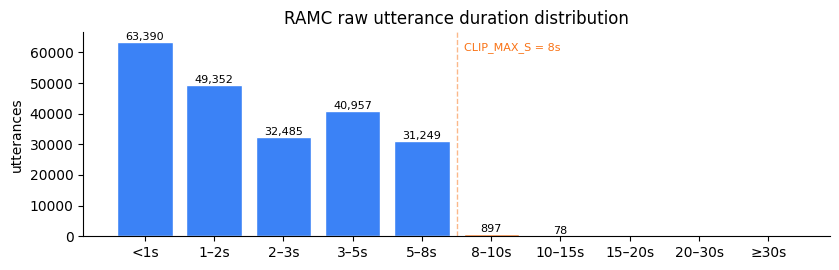

✅ duration distribution shown


In [11]:
# Utterance duration distribution — the *raw* RAMC distribution before
# any candidate-building clips it. Notebook 03 caps every candidate at
# CLIP_MAX_S = 8.0s (so notebook 06's upload chart maxes at 8s); this
# cell shows what that cap is throwing away on the way through.
#
# Buckets line up with the records-tab DurationBucket choices on the
# platform / 06 notebook up to 8s, then extend to capture the long tail
# RAMC actually contains.
import numpy as np
import matplotlib.pyplot as plt

durations = df["duration_s"].astype(float)
print(f"utterances        : {len(durations):,}")
print(f"duration min      : {durations.min():.3f}s")
print(f"duration p50      : {durations.median():.3f}s")
print(f"duration p90      : {durations.quantile(0.90):.3f}s")
print(f"duration p99      : {durations.quantile(0.99):.3f}s")
print(f"duration max      : {durations.max():.3f}s")
n_over_8  = int((durations > 8.0).sum())
n_over_15 = int((durations > 15.0).sum())
print(f"> 8s  (clipped by CLIP_MAX_S in 03)  : {n_over_8:,}  ({100*n_over_8/len(durations):.1f}%)")
print(f"> 15s (very long turns)              : {n_over_15:,}  ({100*n_over_15/len(durations):.1f}%)")

edges  = [0, 1, 2, 3, 5, 8, 10, 15, 20, 30, max(30.001, float(durations.max()) + 0.001)]
labels = ["<1s", "1–2s", "2–3s", "3–5s", "5–8s", "8–10s", "10–15s", "15–20s", "20–30s", "≥30s"]
counts, _ = np.histogram(durations, bins=edges)

fig, ax = plt.subplots(figsize=(8.5, 2.8))
# Colour 8s+ buckets a different shade so the "lost to CLIP_MAX_S" share
# is obvious at a glance.
colours = ["#3b82f6"] * 5 + ["#f97316"] * 5
bars = ax.bar(labels, counts, color=colours, edgecolor="white")
for bar, c in zip(bars, counts):
    if c:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                f"{c:,}", ha="center", va="bottom", fontsize=8)
ax.axvline(4.5, color="#f97316", linestyle="--", linewidth=1, alpha=0.5)
ax.text(4.5, ax.get_ylim()[1] * 0.95, "  CLIP_MAX_S = 8s",
        color="#f97316", fontsize=8, va="top")
ax.set_ylabel("utterances")
ax.set_title("RAMC raw utterance duration distribution")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()
print("✅ duration distribution shown")

## Next

`utterances.parquet` is the single source of truth for every later
notebook in `notebooks/smart-turn-mining/`:

- `02_vad_full_sessions.ipynb` runs Silero VAD on each session WAV and
  saves per-frame probs aligned to these utterances.
- `03_build_candidates.ipynb` joins utterances + VAD to derive
  end-of-turn / continuation candidate clips with the structural rules
  from the plan.